In [1]:
library(tidyverse)
library(stringr)
library(readr)
library(fs)
library(ggplot2)
library(dplyr)
library(broom)
library(tidyr)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.3     ✔ readr     2.1.4
✔ forcats   1.0.0     ✔ stringr   1.5.0
✔ ggplot2   3.4.4     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.0
✔ purrr     1.0.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


In [2]:
options(repos = c(CRAN = "https://cloud.r-project.org"))

if (!require("pacman")) install.packages("pacman")
pacman::p_load(tidyverse, ggplot2, dplyr, lubridate, stringr, readxl, data.table, gdata, scales, data.table)

install.packages("knitr", lib="~/R/x86_64-conda-linux-gnu-library/4.3")
install.packages("rmarkdown", lib="~/R/x86_64-conda-linux-gnu-library/4.3")


Loading required package: pacman



In [8]:
data.2010 <- read_csv("..//data/data-2010.csv")
data.2011 <- read_csv("..//data/data-2011.csv")
data.2012 <- read_csv("..//data/data-2012.csv")
data.2013 <- read_csv("..//data/data-2013.csv")
data.2014 <- read_csv("..//data/data-2014.csv")
data.2015 <- read_csv("..//data/data-2015.csv")

Rows: 108222 Columns: 91
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (15): contractid, state, county, org_type, plan_type, partd, snp, eghp, ...
dbl (66): planid, fips, n_nonmiss, avg_enrollment, sd_enrollment, min_enroll...
lgl (10): partcd_score, risk_star5, risk_star45, risk_star4, risk_star35, ri...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 68003 Columns: 95
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (15): contractid, state, county, org_type, plan_type, partd, snp, eghp, ...
dbl (71): planid, fips, n_nonmiss, avg_enrollment, sd_enrollment, min_enroll...
lgl  (9): risk_star5, risk_star45, risk_star4, risk_star35, risk_star3, risk...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types =

In [9]:
fix_type <- function(df) {
  df$org_parent <- as.character(df$org_parent)
  df
}

data.2011 <- fix_type(data.2011)

In [10]:
combined <- bind_rows(
  data.2010,
  data.2011,
  data.2012,
  data.2013,
  data.2014,
  data.2015
) %>%
  mutate(mkt_share = avg_enrollment / avg_enrolled)

In [11]:
colnames(combined)

[1] "contractid"          "planid"              "fips"               
  [4] "n_nonmiss"           "avg_enrollment"      "sd_enrollment"      
  [7] "min_enrollment"      "max_enrollment"      "first_enrollment"   
 [10] "last_enrollment"     "state"               "county"             
 [13] "org_type"            "plan_type"           "partd"              
 [16] "snp"                 "eghp"                "org_name"           
 [19] "org_marketing_name"  "plan_name"           "parent_org"         
 [22] "contract_date"       "state_long"          "county_long"        
 [25] "n_elig"              "n_enrol"             "avg_eligibles"      
 [28] "sd_eligibles"        "min_eligibles"       "max_eligibles"      
 [31] "first_eligibles"     "last_eligibles"      "avg_enrolled"       
 [34] "sd_enrolled"         "min_enrolled"        "max_enrolled"       
 [37] "first_enrolled"      "last_enrolled"       "ssa"                
 [40] "ncount"              "breastcancer_screen" "rectalcancer_screen"
 [43] "cv_diab_cholscreen"  "glaucoma_test"       "monitoring"         
 [46] "flu_vaccine"         "pn_vaccine"          "physical_health"    
 [49] "mental_health"       "osteo_test"          "physical_monitor"   
 [52] "primaryaccess"       "osteo_manage"        "diab_healthy"       
 [55] "bloodpressure"       "ra_manage"           "copd_test"          
 [58] "bladder"             "falling"             "nodelays"           
 [61] "doctor_communicate"  "carequickly"         "customer_service"   
 [64] "overallrating_care"  "overallrating_plan"  "complaints_plan"    
 [67] "appeals_timely"      "appeals_review"      "leave_plan"         
 [70] "audit_problems"      "hold_times"          "info_accuracy"      
 [73] "ttyt_available"      "new_contract"        "partc_score"        
 [76] "partcd_score"        "Star_Rating"         "aged_parta"         
 [79] "aged_partb"          "risk_ab"             "risk_star5"         
 [82] "risk_star45"         "risk_star4"          "risk_star35"        
 [85] "risk_star3"          "risk_star25"         "risk_bonus5"        
 [88] "risk_bonus35"        "risk_bonus0"         "year"               
 [91] "ma_rate"             "org_parent"          "cv_cholscreen"      
 [94] "diab_cholscreen"     "bmi_assess"          "specialneeds_manage"
 [97] "older_medication"    "older_function"      "older_pain"         
[100] "diabetes_eye"        "diabetes_kidney"     "diabetes_bloodsugar"
[103] "diabetes_chol"       "readmissions"        "coordination"       
[106] "improve"             "X39"                 "X40"                
[109] "low_score"           "X41"                 "X42"                
[112] "access_problems"     "mkt_share"

# Problem 1

In [12]:
# use star_rating for 1-4 and then use partc_score for 5-10

summary_table <- combined %>%
  group_by(year) %>%
  summarise(
    `Mean Star Rating` = round(mean(Star_Rating, na.rm = TRUE), 2),
    `Mean Enrollments` = round(mean(avg_enrollment, na.rm = TRUE), 2),
    `Mean Market Share` = round(mean(mkt_share, na.rm = TRUE), 4),
    `Total Plans` = n()
  )

print(summary_table)

# A tibble: 6 × 5
   year `Mean Star Rating` `Mean Enrollments` `Mean Market Share` `Total Plans`
  <dbl>              <dbl>              <dbl>               <dbl>         <int>
1  2010               2.97               256.              0.0658        108222
2  2011               3.26               343.              0.0855         68003
3  2012               3.36               377.              0.0856         67246
4  2013               3.55               396.              0.0815         67835
5  2014               3.81               437.              0.08           62344
6  2015               3.96               470.              0.0787         65499


# Problem 2

In [13]:
summary_no_rating <- combined %>%
  filter(is.na(Star_Rating)) %>%
  group_by(year) %>%
  summarise(
    `Mean Enrollments` = round(mean(avg_enrollment, na.rm = TRUE), 2),
    `Mean Market Share` = round(mean(mkt_share, na.rm = TRUE), 4),
    `Total Plans` = n()
  )

print(summary_no_rating)

# A tibble: 6 × 4
   year `Mean Enrollments` `Mean Market Share` `Total Plans`
  <dbl>              <dbl>               <dbl>         <int>
1  2010               107.              0.0673         48643
2  2011               168.              0.09           12754
3  2012               173.              0.0567          9077
4  2013               214.              0.06            3661
5  2014               258.              0.0557          3708
6  2015               314.              0.0405          4680


# Problem 3

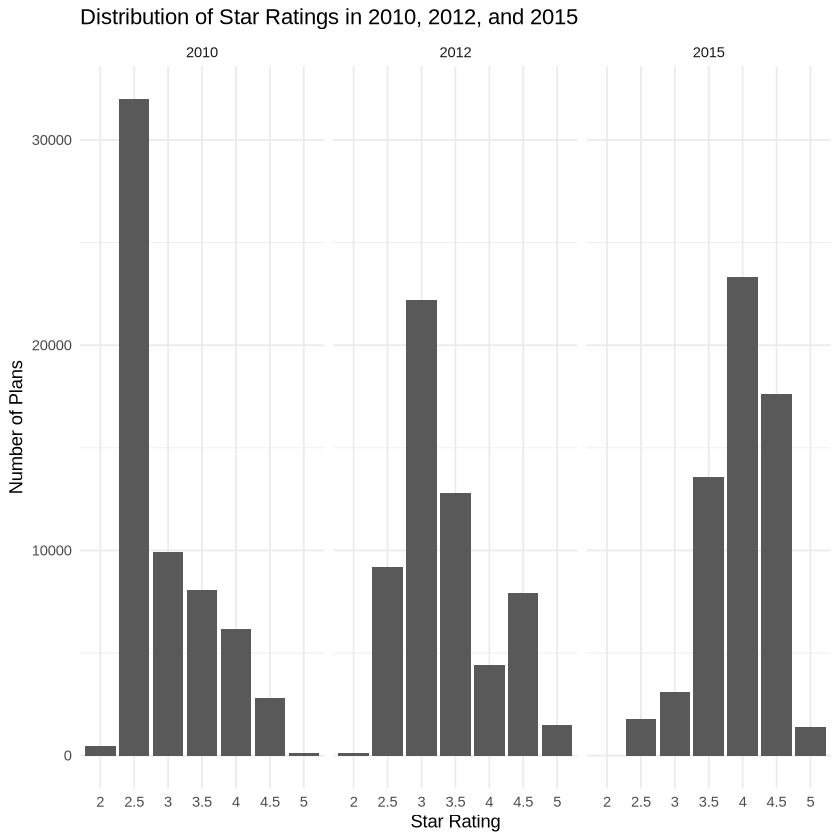

In [14]:
combined %>%
  filter(year %in% c(2010, 2012, 2015), !is.na(Star_Rating)) %>%
  mutate(year = as.factor(year)) %>%
  ggplot(aes(x = as.factor(Star_Rating))) +
  geom_bar() +
  facet_wrap(~ year) +
  labs(
    title = "Distribution of Star Ratings in 2010, 2012, and 2015",
    x = "Star Rating",
    y = "Number of Plans"
  ) +
  theme_minimal()

# Problem 4

In [15]:
combined <- combined %>%
  mutate(
    star_3   = as.integer(Star_Rating == 3),
    star_35  = as.integer(Star_Rating== 3.5),
    star_4   = as.integer(Star_Rating == 4),
    star_45  = as.integer(Star_Rating >= 4.5)
  )

results_list <- list()

for(yr in 2010:2015){
  cat("\nYear:", yr, "\n")
  ols <- lm(mkt_share ~ star_3 + star_35 + star_4 + star_45, 
            data = combined %>% filter(year == yr, !is.na(Star_Rating), !is.na(mkt_share)))
  print(summary(ols))
}



Year: 2010 

Call:
lm(formula = mkt_share ~ star_3 + star_35 + star_4 + star_45, 
    data = combined %>% filter(year == yr, !is.na(Star_Rating), 
        !is.na(mkt_share)))

Residuals:
     Min       1Q   Median       3Q      Max 
-0.07593 -0.05415 -0.03449  0.01530  0.72831 

Coefficients:
              Estimate Std. Error t value Pr(>|t|)    
(Intercept)  0.0633531  0.0009855  64.288  < 2e-16 ***
star_3       0.0126028  0.0018242   6.908 5.05e-12 ***
star_35      0.0005280  0.0018955   0.279  0.78059    
star_4      -0.0036213  0.0021302  -1.700  0.08916 .  
star_45     -0.0075592  0.0026960  -2.804  0.00505 ** 
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.09138 on 18988 degrees of freedom
Multiple R-squared:  0.003954,	Adjusted R-squared:  0.003744 
F-statistic: 18.84 on 4 and 18988 DF,  p-value: 1.788e-15


Year: 2011 

Call:
lm(formula = mkt_share ~ star_3 + star_35 + star_4 + star_45, 
    data = combined %>% filter(year == yr,

In [16]:
results_list <- list()

for(yr in 2010:2015){
  ols <- lm(mkt_share ~ star_3 + star_35 + star_4 + star_45, 
            data = combined %>% filter(year == yr, !is.na(partc_score), !is.na(mkt_share)))
  results_list[[as.character(yr)]] <- coef(ols)
}

ols_table <- as.data.frame(results_list)
colnames(ols_table) <- c("2010", "2011", "2012", "2013", "2014", "2015")
rownames(ols_table) <- c("Intercept (≤2.5 stars)", "3 Stars", "3.5 Stars", "4 Stars", "4.5+ Stars")

print(round(ols_table, 4))

                          2010    2011    2012   2013   2014   2015
Intercept (≤2.5 stars)  0.0634  0.0702  0.0789 0.0491 0.0640 0.0606
3 Stars                 0.0126  0.0350  0.0307 0.0621 0.0276 0.0271
3.5 Stars               0.0005  0.0191  0.0129 0.0385 0.0274 0.0388
4 Stars                -0.0036  0.0028 -0.0246 0.0172 0.0074 0.0115
4.5+ Stars             -0.0076 -0.0095 -0.0134 0.0222 0.0071 0.0233


# Problem 5

build raw rating then filter

In [41]:
datanew.2010 <- data.2010 %>%
  mutate(mkt_share = avg_enrollment / avg_enrolled) %>%
  mutate(
    raw_rating = rowMeans(cbind(
      breastcancer_screen, rectalcancer_screen, cv_diab_cholscreen,
      glaucoma_test, monitoring, flu_vaccine, pn_vaccine,
      physical_health, mental_health, osteo_test, physical_monitor,
      primaryaccess, osteo_manage, diab_healthy, bloodpressure,
      ra_manage, copd_test, bladder, falling, nodelays,
      doctor_communicate, carequickly, customer_service,
      overallrating_care, overallrating_plan, complaints_plan,
      appeals_timely, appeals_review, leave_plan, audit_problems,
      hold_times, info_accuracy, ttyt_available
    ), na.rm = TRUE)
  ) %>%
  distinct(contractid, fips, .keep_all = TRUE)  # this is to make sure it's one row per plan

In [72]:
quality_vars <- c(
  "breastcancer_screen",
  "rectalcancer_screen",
  "cv_diab_cholscreen",
  "glaucoma_test",
  "monitoring",
  "flu_vaccine",
  "pn_vaccine",
  "physical_health",
  "mental_health",
  "osteo_test",
  "physical_monitor",
  "primaryaccess",
  "osteo_manage",
  "diab_healthy",
  "bloodpressure",
  "ra_manage",
  "copd_test",
  "bladder",
  "falling",
  "nodelays",
  "doctor_communicate",
  "carequickly",
  "customer_service",
  "overallrating_care",
  "overallrating_plan",
  "complaints_plan",
  "appeals_timely",
  "appeals_review",
  "leave_plan",
  "audit_problems",
  "hold_times",
  "info_accuracy",
  "ttyt_available"
)

datanew.2010 <- data.2010 %>%
  mutate(
    mkt_share = avg_enrollment / avg_enrolled)  %>%
    rowwise() %>%
  mutate(
    raw_rating = mean(c_across(all_of(quality_vars)), na.rm = TRUE)
  ) %>%
  ungroup()

In [73]:
colnames(datanew.2010)

[1] "contractid"          "planid"              "fips"               
 [4] "n_nonmiss"           "avg_enrollment"      "sd_enrollment"      
 [7] "min_enrollment"      "max_enrollment"      "first_enrollment"   
[10] "last_enrollment"     "state"               "county"             
[13] "org_type"            "plan_type"           "partd"              
[16] "snp"                 "eghp"                "org_name"           
[19] "org_marketing_name"  "plan_name"           "parent_org"         
[22] "contract_date"       "state_long"          "county_long"        
[25] "n_elig"              "n_enrol"             "avg_eligibles"      
[28] "sd_eligibles"        "min_eligibles"       "max_eligibles"      
[31] "first_eligibles"     "last_eligibles"      "avg_enrolled"       
[34] "sd_enrolled"         "min_enrolled"        "max_enrolled"       
[37] "first_enrolled"      "last_enrolled"       "ssa"                
[40] "ncount"              "breastcancer_screen" "rectalcancer_screen"
[43] "cv_diab_cholscreen"  "glaucoma_test"       "monitoring"         
[46] "flu_vaccine"         "pn_vaccine"          "physical_health"    
[49] "mental_health"       "osteo_test"          "physical_monitor"   
[52] "primaryaccess"       "osteo_manage"        "diab_healthy"       
[55] "bloodpressure"       "ra_manage"           "copd_test"          
[58] "bladder"             "falling"             "nodelays"           
[61] "doctor_communicate"  "carequickly"         "customer_service"   
[64] "overallrating_care"  "overallrating_plan"  "complaints_plan"    
[67] "appeals_timely"      "appeals_review"      "leave_plan"         
[70] "audit_problems"      "hold_times"          "info_accuracy"      
[73] "ttyt_available"      "new_contract"        "partc_score"        
[76] "partcd_score"        "Star_Rating"         "aged_parta"         
[79] "aged_partb"          "risk_ab"             "risk_star5"         
[82] "risk_star45"         "risk_star4"          "risk_star35"        
[85] "risk_star3"          "risk_star25"         "risk_bonus5"        
[88] "risk_bonus35"        "risk_bonus0"         "year"               
[91] "ma_rate"             "mkt_share"           "raw_rating"

In [74]:
round_up_counts <- datanew.2010 %>%
  distinct(contractid, fips, .keep_all = TRUE) %>%
  filter(!is.na(raw_rating)) %>%
  filter(!is.na(partc_score)) %>%
  mutate(
    round_ups = ifelse(raw_rating >= 2.75 & raw_rating < 3.00 & partc_score == 3.0, "Rounded up to 3",
               ifelse(raw_rating >= 3.25 & raw_rating < 3.5 & partc_score == 3.5, "Rounded up to 3.5",
               ifelse(raw_rating >= 3.75 & raw_rating < 4.0 & partc_score == 4.0, "Rounded up to 4",
               ifelse(raw_rating >= 4.25 & raw_rating < 4.5 & partc_score == 4.5, "Rounded up to 4.5",
               ifelse(raw_rating >= 4.75 & partc_score == 5.0, "Rounded up to 5",
               NA)))))
  ) %>%
  filter(!is.na(round_ups)) %>%
  count(round_ups) %>%
  rename('Star Rating' = round_ups, 'Number Of Plans' = n)

print(round_up_counts)

# A tibble: 5 × 2
  `Star Rating`     `Number Of Plans`
  <chr>                         <int>
1 Rounded up to 3                1978
2 Rounded up to 3.5              2073
3 Rounded up to 4                1056
4 Rounded up to 4.5               150
5 Rounded up to 5                  15


# Problem 6

In [75]:
run_rd_ols <- function(data, cutoff, stars_below, stars_above) {
  data %>%
    filter(!is.na(raw_rating), !is.na(partc_score),
           partc_score %in% c(stars_below, stars_above)) %>%
    mutate(
      score = raw_rating - cutoff,
      treat = as.integer(score >= 0),
      score_treat = score * treat
    ) %>%
    filter(score >= -0.125, score <= 0.125) %>%
    lm(mkt_share ~ score + treat + score_treat, data = .)
}

star3  <- run_rd_ols(datanew.2010, cutoff = 2.75, stars_below = 2.5, stars_above = 3.0)
star3.5 <- run_rd_ols(datanew.2010, cutoff = 3.25, stars_below = 3.0, stars_above = 3.5)

rename_coefs <- function(mod) {
  s <- summary(mod)
  rownames(s$coefficients) <- c("Intercept", "Running Score", "Rounded", "Running Score x Treat")
  print(s)
}

rename_coefs(star3)
rename_coefs(star3.5)

print (star3)
print (star3.5)


Call:
lm(formula = mkt_share ~ score + treat + score_treat, data = .)

Residuals:
     Min       1Q   Median       3Q      Max 
-0.10400 -0.05003 -0.02918  0.01766  0.69606 

Coefficients:
                       Estimate Std. Error t value Pr(>|t|)    
Intercept              0.016286   0.003355   4.855 1.24e-06 ***
Running Score         -0.740276   0.041505 -17.836  < 2e-16 ***
Rounded                0.054601   0.008311   6.570 5.53e-11 ***
Running Score x Treat  0.957978   0.108914   8.796  < 2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.0955 on 5305 degrees of freedom
  (15955 observations deleted due to missingness)
Multiple R-squared:  0.05949,	Adjusted R-squared:  0.05895 
F-statistic: 111.8 on 3 and 5305 DF,  p-value: < 2.2e-16


Call:
lm(formula = mkt_share ~ score + treat + score_treat, data = .)

Residuals:
     Min       1Q   Median       3Q      Max 
-0.09911 -0.05284 -0.03313  0.01388  0.63867 

Coefficients:
     

In [77]:
results_table <- data.frame(
  Statistic     = c("Intercept", "Rounded", "Running Score", "Num.Obs.", "R2"),
  `3 Stars`     = c(
    round(coef(mod_3star)["(Intercept)"], 3),
    round(coef(mod_3star)["treat"],        3),
    round(coef(mod_3star)["score"],        3),
    nobs(mod_3star),
    round(summary(mod_3star)$r.squared,    3)
  ),
  `3.5 Stars`   = c(
    round(coef(mod_35star)["(Intercept)"], 3),
    round(coef(mod_35star)["treat"],        3),
    round(coef(mod_35star)["score"],        3),
    nobs(mod_35star),
    round(summary(mod_35star)$r.squared,    3)
  ),
  check.names = FALSE
)

print(results_table, row.names = FALSE)

     Statistic  3 Stars 3.5 Stars
     Intercept    0.060     0.155
       Rounded    0.023    -0.120
 Running Score   -0.061     0.510
      Num.Obs. 2430.000   597.000
            R2    0.047     0.060


# Problem 7

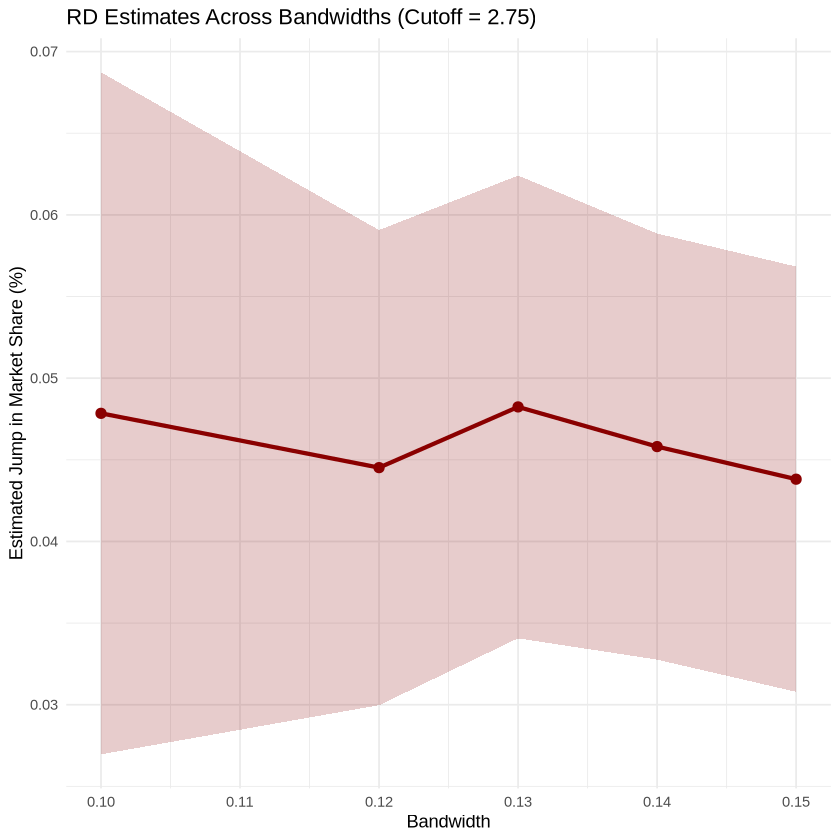

In [78]:
rd1 <- datanew.2010 %>%
  filter(!is.na(raw_rating), !is.na(mkt_share)) %>%
  mutate(score = raw_rating - 2.75)   # center running variable at cutoff


est0.1 <- rdrobust(y = rd1$mkt_share, x = rd1$score, c = 0,
                 h = 0.1, p = 1, kernel = "uniform", vce = "hc0")
est0.12 <- rdrobust(y = rd1$mkt_share, x = rd1$score, c = 0,
                 h = 0.12, p = 1, kernel = "uniform", vce = "hc0")
est0.13 <- rdrobust(y = rd1$mkt_share, x = rd1$score, c = 0,
                 h = 0.13, p = 1, kernel = "uniform", vce = "hc0")
est0.14 <- rdrobust(y = rd1$mkt_share, x = rd1$score, c = 0,
                 h = 0.14, p = 1, kernel = "uniform", vce = "hc0")
est0.15 <- rdrobust(y = rd1$mkt_share, x = rd1$score, c = 0,
                 h = 0.15, p = 1, kernel = "uniform", vce = "hc0")

results_table_275 <- tibble(
  Bandwidth = c(0.10, 0.12, 0.13, 0.14, 0.15),
  Estimate = c(
    est0.1$coef[1],
    est0.12$coef[1],
    est0.13$coef[1],
    est0.14$coef[1],
    est0.15$coef[1]
  ),
  CI_lower = c(
    est0.1$coef[1]  - 1.96 * est0.1$se[1],
    est0.12$coef[1] - 1.96 * est0.12$se[1],
    est0.13$coef[1] - 1.96 * est0.13$se[1],
    est0.14$coef[1] - 1.96 * est0.14$se[1],
    est0.15$coef[1] - 1.96 * est0.15$se[1]
  ),
  CI_upper = c(
    est0.1$coef[1]  + 1.96 * est0.1$se[1],
    est0.12$coef[1] + 1.96 * est0.12$se[1],
    est0.13$coef[1] + 1.96 * est0.13$se[1],
    est0.14$coef[1] + 1.96 * est0.14$se[1],
    est0.15$coef[1] + 1.96 * est0.15$se[1]
  )
)

# print(results_table_275)

ggplot(results_table_275, aes(x = Bandwidth, y = Estimate)) +
  geom_line(size = 1.2, color = "darkred") +
  geom_point(size = 2.5, color = "darkred") +
  geom_ribbon(aes(ymin = CI_lower, ymax = CI_upper), alpha = 0.2, fill = "darkred") +
  scale_y_continuous(breaks = seq(0.00, 0.10, by = 0.01)) +
  labs(
    title = "RD Estimates Across Bandwidths (Cutoff = 2.75)",
    x = "Bandwidth",
    y = "Estimated Jump in Market Share (%)"
  ) +
  theme_minimal()

# A tibble: 5 × 4
  Bandwidth Estimate CI_lower CI_upper
      <dbl>    <dbl>    <dbl>    <dbl>
1      0.1   -0.0651  -0.0860  -0.0443
2      0.12  -0.0458  -0.0604  -0.0313
3      0.13  -0.0493  -0.0634  -0.0351
4      0.14  -0.0540  -0.0671  -0.0410
5      0.15  -0.0232  -0.0362  -0.0102


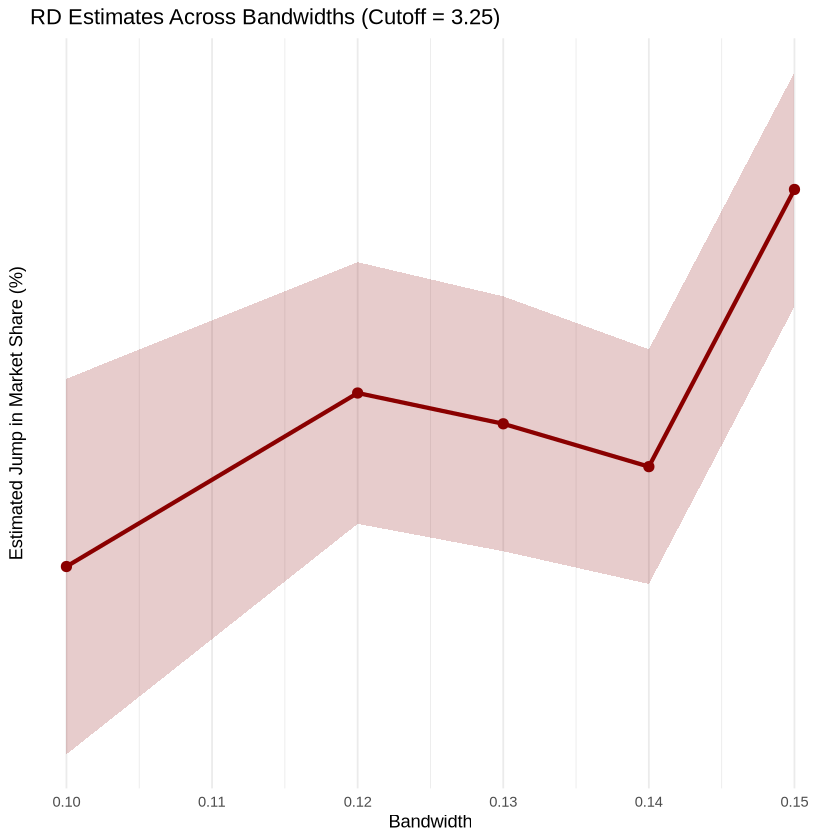

In [37]:
est3 <- rdrobust(y = rd2$mkt_share, x = rd2$score, c = 0,
                 h = 0.1, p = 1, kernel = "uniform", vce = "hc0")

est4 <- rdrobust(y = rd2$mkt_share, x = rd2$score, c = 0,
                 h = 0.12, p = 1, kernel = "uniform", vce = "hc0")

est5 <- rdrobust(y = rd2$mkt_share, x = rd2$score, c = 0,
                 h = 0.13, p = 1, kernel = "uniform", vce = "hc0")

est6 <- rdrobust(y = rd2$mkt_share, x = rd2$score, c = 0,
                 h = 0.14, p = 1, kernel = "uniform", vce = "hc0")

est7 <- rdrobust(y = rd2$mkt_share, x = rd2$score, c = 0,
                 h = 0.15, p = 1, kernel = "uniform", vce = "hc0")

results_table_325 <- tibble(
  Bandwidth = c(0.10, 0.12, 0.13, 0.14, 0.15),
  Estimate = c(
    est3$coef[1],
    est4$coef[1],
    est5$coef[1],
    est6$coef[1],
    est7$coef[1]
  ),
  CI_lower = c(
    est3$coef[1]  - 1.96 * est0.1$se[1],
    est4$coef[1] - 1.96 * est0.12$se[1],
    est5$coef[1] - 1.96 * est0.13$se[1],
    est6$coef[1] - 1.96 * est0.14$se[1],
    est7$coef[1] - 1.96 * est0.15$se[1]
  ),
  CI_upper = c(
    est3$coef[1]  + 1.96 * est0.1$se[1],
    est4$coef[1] + 1.96 * est0.12$se[1],
    est5$coef[1] + 1.96 * est0.13$se[1],
    est6$coef[1] + 1.96 * est0.14$se[1],
    est7$coef[1] + 1.96 * est0.15$se[1]
  )
)

# print(results_table_325)

ggplot(results_table_325, aes(x = Bandwidth, y = Estimate)) +
  geom_line(size = 1.2, color = "darkred") +
  geom_point(size = 2.5, color = "darkred") +
  geom_ribbon(aes(ymin = CI_lower, ymax = CI_upper), alpha = 0.2, fill = "darkred") +
  scale_y_continuous(breaks = seq(0.00, 0.10, by = 0.01)) +
  labs(
    title = "RD Estimates Across Bandwidths (Cutoff = 3.25)",
    x = "Bandwidth",
    y = "Estimated Jump in Market Share (%)"
  ) +
  theme_minimal()


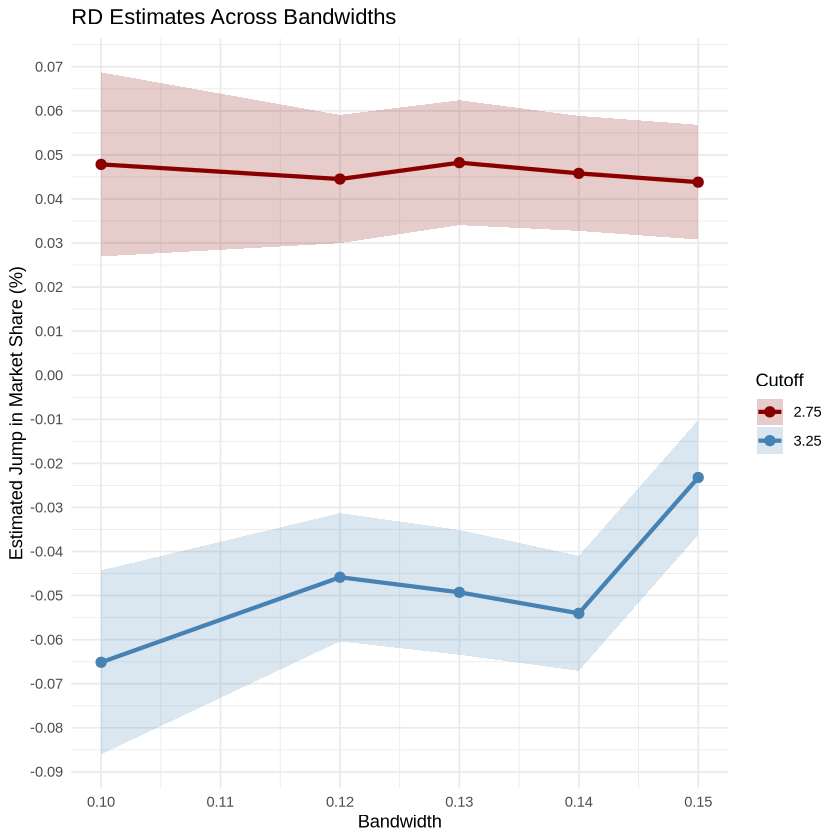

In [40]:
results_combined <- bind_rows(
  results_table_275 %>% mutate(Cutoff = "2.75"),
  results_table_325 %>% mutate(Cutoff = "3.25")
)

ggplot(results_combined, aes(x = Bandwidth, y = Estimate, color = Cutoff, fill = Cutoff)) +
  geom_line(size = 1.2) +
  geom_point(size = 2.5) +
  geom_ribbon(aes(ymin = CI_lower, ymax = CI_upper), alpha = 0.2, color = NA) +
  scale_color_manual(values = c("2.75" = "darkred", "3.25" = "steelblue")) +
  scale_fill_manual(values = c("2.75" = "darkred", "3.25" = "steelblue")) +
  scale_y_continuous(breaks = seq(-0.10, 0.10, by = 0.01)) +  labs(
    title = "RD Estimates Across Bandwidths",
    x = "Bandwidth",
    y = "Estimated Jump in Market Share (%)",
    color = "Cutoff",
    fill = "Cutoff"
  ) +
  theme_minimal()

# set kernel to uniform so that it's not a weighted mean 
# cutoff +- 0.125, run linear regression within that window

# Problem 8

`geom_smooth()` using formula = 'y ~ x'
Warning message:
“Removed 15955 rows containing non-finite values (`stat_smooth()`).”
Warning message:
“Removed 15955 rows containing missing values (`geom_point()`).”


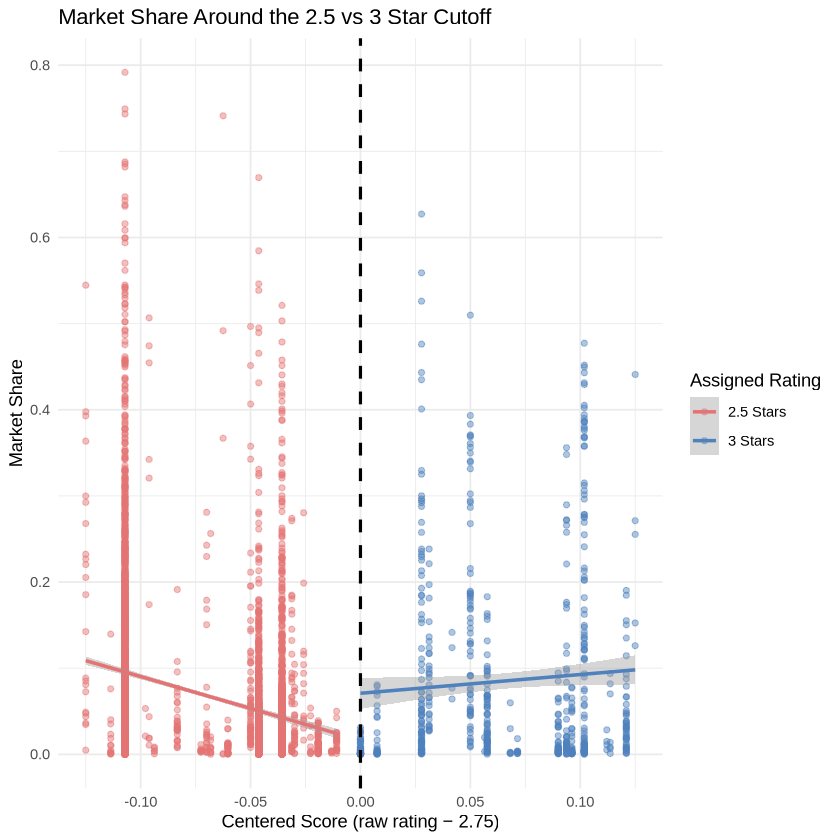

In [82]:
plans_3 <- datanew.2010 %>%
  filter(
    !is.na(raw_rating),
    !is.na(partc_score),
    Star_Rating %in% c(2.5, 3)
  )

band_3 <- plans_3 %>%
  filter(
    raw_rating >= 2.5,
    raw_rating <= 3,
    (raw_rating < 2.75  & Star_Rating == 2.5) |
    (raw_rating >= 2.75 & Star_Rating == 3)
  )

rd_3 <- band_3 %>%
  mutate(
    score = raw_rating - 2.75,          
    treat_group = score >= 0,           
    in_window = between(score, -0.125, 0.125),
    interaction = score * treat_group
  )

p_3 <- ggplot(rd_3 %>% filter(in_window),
             aes(x = score, y = mkt_share, color = treat_group)) +
  geom_point(alpha = 0.45, size = 1.4) +
  geom_smooth(method = "lm", se = TRUE) +
  geom_vline(xintercept = 0, linetype = "dashed", linewidth = 0.9) +
  scale_color_manual(
    values = c("FALSE" = "#E57373", "TRUE" = "#4F81BD"),
    labels = c("2.5 Stars", "3 Stars")
  ) +
  labs(
    title = "Market Share Around the 2.5 vs 3 Star Cutoff",
    x = "Centered Score (raw rating − 2.75)",
    y = "Market Share",
    color = "Assigned Rating"
  ) +
  theme_minimal()

p_3


`geom_smooth()` using formula = 'y ~ x'
Warning message:
“Removed 3641 rows containing non-finite values (`stat_smooth()`).”
Warning message:
“Removed 3641 rows containing missing values (`geom_point()`).”


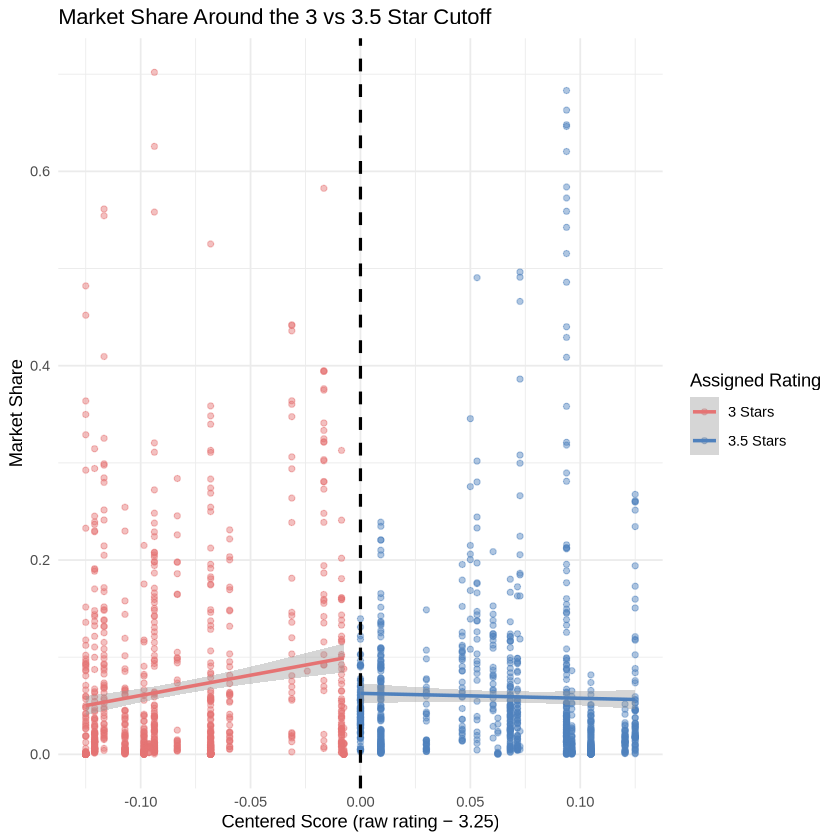

In [83]:
plans_3.5 <- datanew.2010 %>%
  filter(
    !is.na(raw_rating),
    !is.na(partc_score),
    Star_Rating %in% c(3, 3.5)
  )

band_3.5 <- plans_3.5 %>%
  filter(
    raw_rating >= 3,
    raw_rating <= 3.5,
    (raw_rating < 3.25  & Star_Rating == 3) |
    (raw_rating >= 3.25 & Star_Rating == 3.5)
  )

rd_3.5 <- band_3.5 %>%
  mutate(
    score = raw_rating - 3.25,          
    treat_group = score >= 0,      
    in_window = between(score, -0.125, 0.125),
    interaction = score * treat_group
  )

p_3.5 <- ggplot(rd_3.5 %>% filter(in_window), 
             aes(x = score, y = mkt_share, color = treat_group)) +
  geom_point(alpha = 0.45, size = 1.4) +
  geom_smooth(method = "lm", se = TRUE) +
  geom_vline(xintercept = 0, linetype = "dashed", linewidth = 0.9) +
  scale_color_manual(
    values = c("FALSE" = "#E57373", "TRUE" = "#4F81BD"),
    labels = c("3 Stars", "3.5 Stars")
  ) +
  labs(
    title = "Market Share Around the 3 vs 3.5 Star Cutoff",
    x = "Centered Score (raw rating − 3.25)",
    y = "Market Share",
    color = "Assigned Rating"
  ) +
  theme_minimal()

p_3.5


# Problem 9

In [84]:
near_275 <- datanew.2010 %>%
  mutate(
    score = raw_rating - 2.75,
    group = ifelse(score >= 0, "Above cutoff", "Below cutoff")
  ) %>%
  filter(score >= -0.125, score <= 0.125) %>%
  mutate(
    HMO = str_detect(plan_type, "HMO"),
    PartD = partd == "Yes"
  ) %>%
  group_by(group) %>%
  summarise(
    share_HMO = mean(HMO),
    share_PartD = mean(PartD),
    n = n()
  )

cat("Table: Plan Characteristics Around the 2.75 Cutoff\n")
near_275


Table: Plan Characteristics Around the 2.75 Cutoff


group,share_HMO,share_PartD,n
<chr>,<dbl>,<dbl>,<int>
Above cutoff,0.44659810,0.8401899,2528
Below cutoff,0.01943266,0.5491177,22385


In [85]:
near_325 <- datanew.2010 %>%
  mutate(
    score = raw_rating - 3.25,
    group = ifelse(score >= 0, "Above cutoff", "Below cutoff")) %>%
  filter(score >= -0.125, score <= 0.125) %>%
  mutate(
    HMO = str_detect(plan_type, "HMO"),
    PartD = partd == "Yes") %>%
 
group_by(group) %>%
  summarise(
    share_HMO = mean(HMO),
    share_PartD = mean(PartD),
    n = n()
  )

cat("Table: Plan Characteristics Around the 3.25 Cutoff (3–3.5 Stars)\n")
near_325


Table: Plan Characteristics Around the 3.25 Cutoff (3–3.5 Stars)


group,share_HMO,share_PartD,n
<chr>,<dbl>,<dbl>,<int>
Above cutoff,0.3768352,0.8172920,2452
Below cutoff,0.6056941,0.8641975,3969


These tables show you whether plans just above each cutoff look similar to plans just below it. Plans just above the 2.75 threshold are completely different types of plans as the ones above are much more likely to be HMOs and to offer Part D. Plans for just above the 3.25 thresold are slightly different but to a lesser degree. 

# Problem 10 

Overall, a higher star rating shows more enrollment but the comparison is compromised as plans above and below the threshold are different. Raw ratings tend to be more distributed around the thresholds (2.75 and 3.25), and the adjusted ratings create jumps in star assignments. Because plan characteristics are distinct and not comparable right above or below the cutoff, the RD model cannot cleanly isolate the effect of the star rating alone. 